# Taller Práctico Clase 9: Reducción de Dimensionalidad

**Objetivo:** En este taller, aplicaremos y compararemos las tres técnicas de reducción de dimensionalidad vistas en clase: PCA (Análisis de Componentes Principales), t-SNE y UMAP. 

**Dataset:** Usaremos el dataset `digits` de Scikit-learn, que contiene imágenes de 8x8 píxeles de dígitos escritos a mano (0-9). Cada imagen está "aplanada" en un vector de 64 características (dimensiones), lo que lo convierte en un excelente candidato para la reducción de dimensionalidad y la visualización.

## 1. Configuración e Importación de Librerías

In [1]:
# Librerías para manipulación de datos
import numpy as np
import pandas as pd

# Librerías para visualización
import plotly.express as px
import matplotlib.pyplot as plt

# Scikit-learn para carga de datos, preprocesamiento y modelos
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# UMAP (es necesario instalarlo: pip install umap-learn)
import umap

# Configuraciones adicionales
pd.options.plotting.backend = 'plotly'

## 2. Carga y Exploración del Dataset

In [2]:
# Cargamos el dataset de dígitos
digits = load_digits()

# X tiene los datos de las imágenes (las características)
X = digits.data

# y contiene las etiquetas verdaderas (el dígito del 0 al 9)
y = digits.target

print(f"Forma de la matriz de características (X): {X.shape}")
print(f"Forma del vector de etiquetas (y): {y.shape}")

Forma de la matriz de características (X): (1797, 64)
Forma del vector de etiquetas (y): (1797,)


Cada imagen tiene 64 píxeles (8x8), que actúan como nuestras características. Tenemos 1797 imágenes en total.

Para tener una idea de cómo se ven los datos, podemos visualizar algunas de las imágenes.

In [3]:
digits.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [4]:
digits.data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

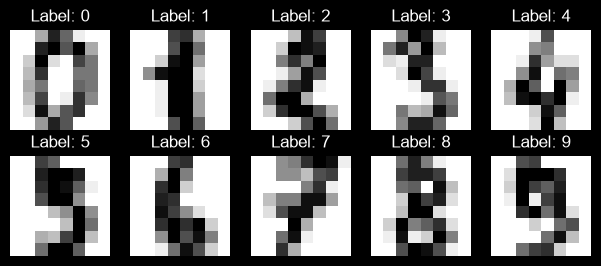

In [5]:
plt.figure(figsize=(7.5, 3))
for index, (image, label) in enumerate(zip(digits.images[:10], digits.target[:10])):
    plt.subplot(2, 5, index + 1)
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.axis('off')
    plt.title('Label: %i' % label)
plt.show()

## 3. Preprocesamiento: Escalado de Datos

Como vimos en la teoría, PCA es sensible a la escala de las características. Aunque en este caso todos los píxeles están en una escala similar (0-16), es una buena práctica estandarizar los datos para que tengan media 0 y desviación estándar 1. Esto asegura que cada característica contribuya por igual al análisis.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. Análisis de Componentes Principales (PCA)

Comenzaremos aplicando PCA para reducir la dimensionalidad de 64 a 2 componentes para poder visualizar los datos en un gráfico de dispersión.

### 4.1. Varianza Explicada

Antes de reducir a 2D, es útil ajustar PCA con todos los componentes posibles para ver cuánta varianza explica cada uno. El **Scree Plot** nos ayudará a decidir cuántos componentes son "suficientes".

In [7]:
# Ajustamos PCA sin especificar n_components para mantenerlos todos
pca_full = PCA()
pca_full.fit(X_scaled)

# Calculamos la varianza explicada acumulada
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Creamos el Scree Plot
fig = px.area(x=range(1, cumulative_variance.shape[0] + 1),
              y=cumulative_variance,
              labels={"x": "Número de Componentes Principales", "y": "Varianza Explicada Acumulada"},
              title="Scree Plot: Varianza Explicada por los Componentes Principales")
fig.update_layout(yaxis_range=[0,1.05])
fig.add_hline(y=0.9, line_dash="dash", line_color="red")
fig.add_annotation(x=30, y=0.9, text="90% de Varianza Explicada", showarrow=True, arrowhead=1)
fig.show()

**Interpretación:** Podemos ver que con aproximadamente 10 componentes ya capturamos más del 60% de la varianza, y con unos 30 componentes, superamos el 90%. Esto nos dice que hay mucha redundancia en los 64 píxeles y que podemos representar los datos con mucha menos información sin una pérdida masiva.

Ahora, vamos a reducir a solo 2 componentes para la visualización.

### 4.2. Reducción a 2D y Visualización

In [8]:
# Aplicamos PCA para reducir a 2 dimensiones
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

# Creamos un DataFrame para facilitar la visualización con Plotly
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['label'] = y.astype(str) # Convertimos la etiqueta a string para colores discretos

# Visualizamos
fig = px.scatter(df_pca, x='PC1', y='PC2', color='label',
                 title='Visualización del Dataset Digits con PCA (2 Componentes)',
                 labels={'color': 'Dígito'})
fig.show()

**Análisis de PCA:** PCA logra una separación decente para algunos dígitos (como el 0, 4 y 6), pero muchos otros se superponen significativamente. Esto es esperado, ya que PCA está limitado a proyecciones lineales.

## 5. t-SNE (t-distributed Stochastic Neighbor Embedding)

Ahora, aplicaremos t-SNE, una técnica no lineal, para ver si podemos obtener una mejor separación visual de los clusters de dígitos.

In [9]:
# Aplicamos t-SNE. Perplexity es un hiperparámetro importante.
tsne = TSNE(n_components=2, perplexity=100, random_state=1)
X_tsne = tsne.fit_transform(X_scaled)

# Creamos el DataFrame para Plotly
df_tsne = pd.DataFrame(data=X_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne['label'] = y.astype(str)

# Visualizamos
fig = px.scatter(df_tsne, x='TSNE1', y='TSNE2', color='label',
                 title='Visualización del Dataset Digits con t-SNE',
                 labels={'color': 'Dígito'})
fig.show()

**Análisis de t-SNE:** ¡El resultado es drásticamente mejor! t-SNE logra formar clusters muy definidos y separados para cada dígito. Esto demuestra el poder de los métodos no lineales para visualizar estructuras de datos complejas. Recordemos la advertencia: las distancias entre los clusters en t-SNE no son necesariamente significativas.

## 6. UMAP (Uniform Manifold Approximation and Projection)

Finalmente, probaremos UMAP, la alternativa moderna a t-SNE.

In [10]:
# Aplicamos UMAP. n_neighbors y min_dist son hiperparámetros clave.
reducer = umap.UMAP(n_neighbors=15, min_dist=0.0, n_components=2)
X_umap = reducer.fit_transform(X_scaled)

# Creamos el DataFrame para Plotly
df_umap = pd.DataFrame(data=X_umap, columns=['UMAP1', 'UMAP2'])
df_umap['label'] = y.astype(str)

# Visualizamos
fig = px.scatter(df_umap, x='UMAP1', y='UMAP2', color='label',
                 title='Visualización del Dataset Digits con UMAP',
                 labels={'color': 'Dígito'})
fig.show()

**Análisis de UMAP:** UMAP también produce una excelente separación de los clusters, similar a t-SNE. A menudo, UMAP es mucho más rápido que t-SNE (aunque en este dataset pequeño la diferencia no es tan notable) y puede preservar mejor la estructura global de los datos. Observa cómo algunos clusters (como el '4' y el '7') pueden aparecer más cercanos entre sí, lo que podría reflejar una mayor similitud intrínseca.

## 7. Conclusiones del Taller

- **PCA** es una herramienta rápida y útil para una reducción de dimensionalidad lineal. Es excelente como paso de preprocesamiento, pero puede no ser la mejor para la visualización de estructuras complejas.
- **t-SNE** es excepcional para revelar la estructura de clusters locales en los datos, produciendo visualizaciones muy claras y separadas.
- **UMAP** ofrece resultados de visualización de alta calidad, a menudo comparables o superiores a los de t-SNE, pero con la ventaja de ser significativamente más rápido y, a menudo, preservar mejor la estructura global de los datos.

---

## ✍️ Ejercicios Propuestos

1.  **Varianza en PCA:** ¿Cuántos componentes principales son necesarios para explicar el 95% de la varianza en el dataset `digits`? Vuelve a ejecutar el análisis del Scree Plot y encuentra el número exacto.

2.  **Experimenta con t-SNE:** Modifica el hiperparámetro `perplexity` en el modelo t-SNE a valores más bajos (ej. 5) y más altos (ej. 200). ¿Cómo cambia la visualización? ¿Qué parece controlar este parámetro?

3.  **Experimenta con UMAP:** Modifica el hiperparámetro `n_neighbors` en el modelo UMAP a valores más bajos (ej. 5) y más altos (ej. 50). ¿Cómo afecta esto a la separación de los clusters y a la estructura global?

4.  **Visualización 3D:** Adapta el código de PCA, t-SNE y UMAP para reducir los datos a 3 componentes (`n_components=3`). Utiliza `plotly.express.scatter_3d` para crear visualizaciones tridimensionales. ¿Añade la tercera dimensión una mejor perspectiva?

5.  **Impacto en un Clasificador:** Entrena un modelo simple, como `LogisticRegression` de Scikit-learn, sobre los datos originales escalados (`X_scaled`). Luego, entrena el mismo modelo sobre los datos reducidos por PCA (usando suficientes componentes para capturar el 95% de la varianza). Compara el tiempo de entrenamiento y la precisión (accuracy) de ambos modelos. ¿Qué observas?

6.  **Interpretando los Componentes Principales:** El objeto `pca_2d` contiene los `components_` (loadings). Cada componente es un vector de 64 elementos. "Reforma" (`reshape`) el primer componente principal a una imagen de 8x8 y visualízalo con `plt.imshow`. ¿Qué parece representar este componente? ¿Qué píxeles son los más importantes?

7.  **Aplicación a otro Dataset:** Carga el dataset `load_wine` de Scikit-learn. Este dataset tiene 13 características. Aplica PCA, t-SNE y UMAP para visualizar las 3 clases de vinos. ¿Cuál técnica funciona mejor para separar las clases?
le? ¿Por qué?


**Observación sobre el punto 5:**
En mi PC observé los siguientes datos de accuracy y tiempo, como para darles una referencia:

| Métrica                     | Modelo Original | Modelo con PCA |
|-----------------------------|----------------|---------------|
| Número de Características   | 64             | 39            |
| Tiempo de Entrenamiento     | 0.0340         | 0.0062        |
| Precisión (Accuracy)        | 0.9796         | 0.9630        |

In [11]:
'''
1. Varianza en PCA: ¿Cuántos componentes principales son necesarios para explicar
el 95% de la varianza en el dataset digits? Vuelve a ejecutar el análisis del
Scree Plot y encuentra el número exacto.

40 componentes principales son necesarios para explicar el 95% de la varianza.
'''

# Ajustamos PCA sin especificar n_components para mantenerlos todos
pca_full = PCA()
pca_full.fit(X_scaled)

# Calculamos la varianza explicada acumulada
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Número de componentes necesarios para 95%
n_comp_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Número de componentes necesarios para explicar el 95% de la varianza: {n_comp_95}")

# Creamos el Scree Plot
fig = px.area(
    x=range(1, cumulative_variance.shape[0] + 1),
    y=cumulative_variance,
    labels={"x": "Número de Componentes Principales", "y": "Varianza Explicada Acumulada"},
    title="Scree Plot: Varianza Explicada por los Componentes Principales"
)

# Ajuste de ejes
fig.update_layout(yaxis_range=[0, 1.05])

# Línea horizontal en 95%
fig.add_hline(y=0.95, line_dash="dash", line_color="red")

# Línea vertical en el número de componentes encontrados
fig.add_vline(x=n_comp_95, line_dash="dash", line_color="green")

fig.add_annotation(
    x=n_comp_95,
    y=0.95,
    text=f"{n_comp_95} componentes para 95% de varianza",
    showarrow=True,
    arrowhead=1
)

fig.show()

Número de componentes necesarios para explicar el 95% de la varianza: 40


In [12]:
'''
2. Experimenta con t-SNE: Modifica el hiperparámetro perplexity en el modelo
t-SNE a valores más bajos (ej. 5) y más altos (ej. 200). ¿Cómo cambia la
visualización? ¿Qué parece controlar este parámetro?
'''
perplexities = [5, 100, 200]

for p in perplexities:
    tsne = TSNE(n_components=2, perplexity=p, random_state=1)
    X_tsne = tsne.fit_transform(X_scaled)

    df_tsne = pd.DataFrame(data=X_tsne, columns=['TSNE1', 'TSNE2'])
    df_tsne['label'] = y.astype(str)

    # Visualizamos
    fig = px.scatter(df_tsne, x='TSNE1', y='TSNE2', color='label',
                    title=f'Visualización del Dataset Digits con t-SNE (Perplexity={p})',
                    labels={'color': 'Dígito'})
    fig.show()

'''
El parámetro de perplexity controla el "radio de vecindad" que el método
utiliza para construir su distribucion de probabilidad.

Un valor bajo de perplexity preserva las características de clusters pequeños
y su relación con vecinos próximos.

Un valor más alto de perplexity tendra en cuenta vecinos mas distantes, y
dará mayor información acerca de la estructura global de los datos.
'''

'\nEl parámetro de perplexity controla el "radio de vecindad" que el método\nutiliza para construir su distribucion de probabilidad.\n\nUn valor bajo de perplexity preserva las características de clusters pequeños\ny su relación con vecinos próximos.\n\nUn valor más alto de perplexity tendra en cuenta vecinos mas distantes, y\ndará mayor información acerca de la estructura global de los datos.\n'

In [18]:
'''
3. Experimenta con UMAP: Modifica el hiperparámetro n_neighbors en el modelo
UMAP a valores más bajos (ej. 5) y más altos (ej. 50). ¿Cómo afecta esto a la
separación de los clusters y a la estructura global?
'''
neighbors = [5, 15, 50]

for n in neighbors:
  reducer = umap.UMAP(n_neighbors=n, min_dist=0.0, n_components=2)
  X_umap = reducer.fit_transform(X_scaled)

  # Creamos el DataFrame para Plotly
  df_umap = pd.DataFrame(data=X_umap, columns=['UMAP1', 'UMAP2'])
  df_umap['label'] = y.astype(str)

  # Visualizamos
  fig = px.scatter(df_umap, x='UMAP1', y='UMAP2', color='label',
                  title=f'Visualización del Dataset Digits con UMAP (Neighbors: {n})',
                  labels={'color': 'Dígito'})
  fig.show()

'''
El parámetro de n_neighbors es conceptualmente similar al de perplexity en TNSE.
Sirve para ajustar lo que se considera local vs global.

Un valor bajo de n_neighbors proporcionará mayor información sobre la estructura
local. Por el contrario, un valor alto de n_neighbors dará una visión más global.
'''

'\nEl parámetro de n_neighbors es conceptualmente similar al de perplexity en TNSE.\nSirve para ajustar lo que se considera local vs global.\n\nUn valor bajo de n_neighbors proporcionará mayor información sobre la estructura\nlocal. Por el contrario, un valor alto de n_neighbors dará una visión más global.\n'

In [14]:
'''
4. Visualización 3D: Adapta el código de PCA, t-SNE y UMAP para reducir los
datos a 3 componentes (n_components=3). Utiliza plotly.express.scatter_3d para
crear visualizaciones tridimensionales.
¿Añade la tercera dimensión una mejor perspectiva?
'''
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

df_pca_3d = pd.DataFrame(data=X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca_3d['label'] = y.astype(str)

fig = px.scatter(df_pca_3d, x='PC1', y='PC2', color='label',
                 title='Visualización del Dataset Digits con PCA (2 Componentes)',
                 labels={'color': 'Dígito'})
fig.show()
fig = px.scatter_3d(df_pca_3d, x='PC1', y='PC2', z='PC3', color='label',
                 title='Visualización del Dataset Digits con PCA (3 Componentes)',
                 labels={'color': 'Dígito'})
fig.show()


tsne_3d = TSNE(n_components=3, perplexity=100, random_state=1)
X_tsne_3d = tsne_3d.fit_transform(X_scaled)
df_tsne_3d = pd.DataFrame(data=X_tsne_3d, columns=['TSNE1', 'TSNE2', 'TSNE3'])
df_tsne_3d['label'] = y.astype(str)

fig = px.scatter(df_tsne_3d, x='TSNE1', y='TSNE2', color='label',
                 title='Visualización del Dataset Digits con t-SNE (2 componentes)',
                 labels={'color': 'Dígito'})
fig.show()
fig = px.scatter_3d(df_tsne_3d, x='TSNE1', y='TSNE2', z="TSNE3", color='label',
                 title='Visualización del Dataset Digits con t-SNE (3 Componentes)',
                 labels={'color': 'Dígito'})
fig.show()


reducer_3d = umap.UMAP(n_neighbors=15, min_dist=0.0, n_components=3)
X_umap_3d = reducer_3d.fit_transform(X_scaled)

df_umap_3d = pd.DataFrame(data=X_umap_3d, columns=['UMAP1', 'UMAP2', 'UMAP3'])
df_umap_3d['label'] = y.astype(str)

fig = px.scatter(df_umap_3d, x='UMAP1', y='UMAP2', color='label',
                 title='Visualización del Dataset Digits con UMAP (2 componentes)',
                 labels={'color': 'Dígito'})
fig.show()

fig = px.scatter_3d(df_umap_3d, x='UMAP1', y='UMAP2', z='UMAP3', color='label',
                 title='Visualización del Dataset Digits con UMAP (3 Componentes)',
                 labels={'color': 'Dígito'})
fig.show()

'''
Verlo en tres dimensiones te permite entender mejor cómo están agrupados los
datos. Lo que en 2D parece que son clusters superpuestos, en realidad no lo son:
están separados en el espacio, solo que la proyección plana los aplasta y los
hace parecer solapados.
'''

'\nVerlo en tres dimensiones te permite entender mejor cómo están agrupados los\ndatos. Lo que en 2D parece que son clusters superpuestos, en realidad no lo son:\nestán separados en el espacio, solo que la proyección plana los aplasta y los\nhace parecer solapados.\n'

In [15]:
'''
5. Impacto en un Clasificador: Entrena un modelo simple, como LogisticRegression
de Scikit-learn, sobre los datos originales escalados (X_scaled). Luego, entrena
el mismo modelo sobre los datos reducidos por PCA (usando suficientes
componentes para capturar el 95% de la varianza). Compara el tiempo de
entrenamiento y la precisión (accuracy) de ambos modelos. ¿Qué observas?
'''
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LogisticRegression(random_state=42)
start_time = time.perf_counter()
model.fit(X_train_scaled, y_train)
end_time = time.perf_counter()

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
elapsed = end_time - start_time

print("WITHOUT PCA")
print(f"Number of characteristics: {X_train_scaled.shape[1]}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Training time: {elapsed:.4f} seconds")


pca_40 = PCA(n_components=40)
X_train_pca_40 = pca_40.fit_transform(X_train_scaled)
X_test_pca_40 = pca_40.transform(X_test_scaled)

model_pca = LogisticRegression(random_state=42)
start_time_pca = time.perf_counter()
model_pca.fit(X_train_pca_40, y_train)
end_time_pca = time.perf_counter()

y_pred_pca = model_pca.predict(X_test_pca_40)
accuracy_pca = accuracy_score(y_test, y_pred_pca)
elapsed_pca = end_time_pca - start_time_pca

print("\nWITH PCA")
print(f"Number of characteristics: {X_test_pca_40.shape[1]}")
print(f"Accuracy: {accuracy_pca:.4f}")
print(f"Training time: {elapsed_pca:.4f} seconds")

'''
Para el dataset actual, el entrenamiento usando 40 caracteristicas principales
muestra una accuracy practicamente igual, ayudando a simplificar el modelo.
Los resultados en cambios en los tiempos de entrenamiento no son consistentes.
Como el dataset digits no es muy grande, las diferencias no es claras ni consistente.
'''

WITHOUT PCA
Number of characteristics: 64
Accuracy: 0.9667
Training time: 0.0097 seconds

WITH PCA
Number of characteristics: 40
Accuracy: 0.9611
Training time: 0.0076 seconds


'\nPara el dataset actual, el entrenamiento usando 40 caracteristicas principales\nmuestra una accuracy practicamente igual, ayudando a simplificar el modelo.\nLos resultados en cambios en los tiempos de entrenamiento no son consistentes.\nComo el dataset digits no es muy grande, las diferencias no es claras ni consistente.\n'

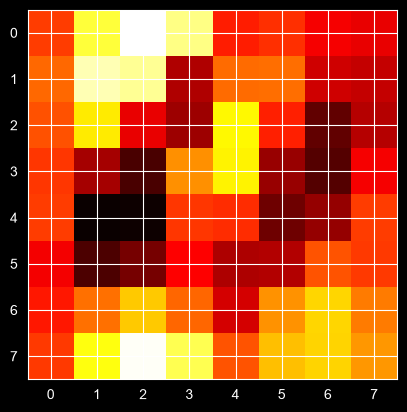

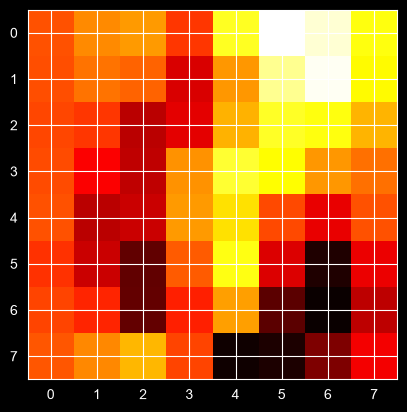

'\nLos píxeles más importantes son aquellos que aparecen como zonas muy claras o,\nlo que indica que tienen valores absolutos altos. Esto significa que el PCA\nidentifica estos píxeles como los que más contribuyen a la variabilidad.\n'

In [16]:
'''
6. Interpretando los Componentes Principales: El objeto pca_2d contiene los
components_ (loadings). Cada componente es un vector de 64 elementos. "Reforma"
(reshape) el primer componente principal a una imagen de 8x8 y visualízalo con
plt.imshow. ¿Qué parece representar este componente?
¿Qué píxeles son los más importantes?
'''

for comp in pca_2d.components_:
  img = comp.reshape((8, 8))
  plt.imshow(img, cmap='hot')
  plt.show()

'''
Los píxeles más importantes son aquellos que aparecen como zonas muy claras o,
lo que indica que tienen valores absolutos altos. Esto significa que el PCA
identifica estos píxeles como los que más contribuyen a la variabilidad.
'''

In [17]:
'''
7. **Aplicación a otro Dataset:** Carga el dataset `load_wine` de Scikit-learn. Este dataset tiene 13 características.
Aplica PCA, t-SNE y UMAP para visualizar las 3 clases de vinos. ¿Cuál técnica funciona mejor para separar las clases?
le? ¿Por qué?
'''

import plotly.express as px
from sklearn.datasets import load_wine

wine = load_wine()
X = wine.data
y = wine.target

X_scaled = StandardScaler().fit_transform(X)

# === PCA ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=["PC1","PC2"])
df_pca["class"] = y.astype(str)
fig_pca = px.scatter(df_pca, x="PC1", y="PC2", color="class", title="PCA - Wine Dataset")
fig_pca.show()

# === t-SNE ===
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
df_tsne = pd.DataFrame(X_tsne, columns=["TSNE1","TSNE2"])
df_tsne["class"] = y.astype(str)
fig_tsne = px.scatter(df_tsne, x="TSNE1", y="TSNE2", color="class", title="t-SNE - Wine Dataset")
fig_tsne.show()

# === UMAP ===
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)
df_umap = pd.DataFrame(X_umap, columns=["UMAP1","UMAP2"])
df_umap["class"] = y.astype(str)
fig_umap = px.scatter(df_umap, x="UMAP1", y="UMAP2", color="class", title="UMAP - Wine Dataset")
fig_umap.show()

'''
PCA

El gráfico muestra que PCA logra una separación parcial de las clases.
PCA es un método lineal y solo maximiza la varianza proyectada, por lo que puede perder capacidad para capturar relaciones más complejas entre las variables.

t-SNE

La visualización con t-SNE produce tres clusters bien definidos y bastante separados, lo que facilita distinguir claramente las tres clases de vino.
Este método aprovecha su capacidad de preservar la estructura local de los datos.

UMAP

UMAP también muestra una separación muy clara de las tres clases, con clusters bien definidos.
A diferencia de t-SNE, UMAP mantiene mejor la estructura global, es decir, las distancias relativas entre grupos también son significativas.

Finalmente,
UMAP puede considerarse la mejor opción porque combina buena separación local con preservación de la estructura global, ofreciendo un balance más estable y representativo de los datos.
'''

/Users/matlock/Desktop/personal/personal-mac-old/UdeSa - ML 1/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


'\nPCA\n\nEl gráfico muestra que PCA logra una separación parcial de las clases.\nPCA es un método lineal y solo maximiza la varianza proyectada, por lo que puede perder capacidad para capturar relaciones más complejas entre las variables.\n\nt-SNE\n\nLa visualización con t-SNE produce tres clusters bien definidos y bastante separados, lo que facilita distinguir claramente las tres clases de vino.\nEste método aprovecha su capacidad de preservar la estructura local de los datos.\n\nUMAP\n\nUMAP también muestra una separación muy clara de las tres clases, con clusters bien definidos.\nA diferencia de t-SNE, UMAP mantiene mejor la estructura global, es decir, las distancias relativas entre grupos también son significativas.\n\nFinalmente,\nUMAP puede considerarse la mejor opción porque combina buena separación local con preservación de la estructura global, ofreciendo un balance más estable y representativo de los datos.\n'